In [25]:
using Distributions,Statistics,Random,Gillespie,Plots,StatsBase

In [26]:
function F(x,parms)
    
    mRNA, p = x

    (k_transcr,k_deg_t,k_transl,k_deg_p) = parms
    
    transcription = k_transcr
    mRNA_degradation = k_deg_t*mRNA
    translation = k_transl*mRNA
    p_degradation = k_deg_p*p
    
    [transcription, mRNA_degradation, translation, p_degradation]
end

F (generic function with 1 method)

In [27]:
nu = [[1 0];
    [-1 0];
    [0 1];
    [0 -1]]

4×2 Matrix{Int64}:
  1   0
 -1   0
  0   1
  0  -1

In [28]:
# esempio singola simulazione

# condizioni iniziali specie
x0=[0, 0]

#valori rate
k_transcr=0.06
k_deg_t=0.006
k_transl=0.04
k_deg_p=0.002
      
#array parametri
parms=[k_transcr,k_deg_t,k_transl,k_deg_p]

#tempo max
t_f = 20000.0

#simulazione
res = ssa(x0,F,nu,parms,t_f)

#step temporali
time_steps = res.time

#traiettoria specie 1 (mRNA)
mRNA_traj = res.data[:,1]

#traiettoria specie 2 (proteina)
p_traj = res.data[:,2]

18563-element Vector{Int64}:
   0
   0
   1
   1
   2
   3
   3
   3
   4
   5
   ⋮
 140
 139
 138
 139
 140
 140
 141
 140
 141

In [ ]:
res

In [ ]:
res.time

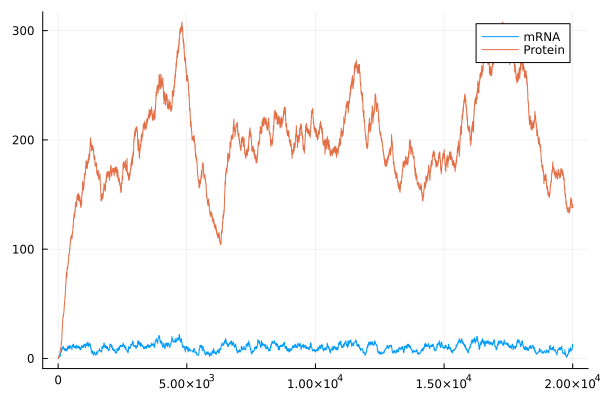

In [29]:
plot(time_steps, mRNA_traj, legend=:topright, label="mRNA")
plot!(time_steps, p_traj, label="Protein")

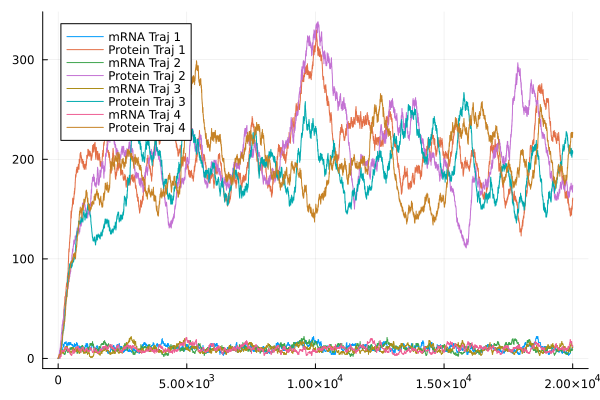

In [30]:
# Plotting many trajectories
t_f = 20000.0
n_trajectories = 4
x = plot()
for i in 1:n_trajectories
    res = ssa(x0,F,nu,parms,t_f)
    time_steps = res.time
    mRNA_traj = res.data[:,1]
    p_traj = res.data[:,2]
    plot!(time_steps, mRNA_traj, label="mRNA Traj $i")
    plot!(time_steps, p_traj, label="Protein Traj $i")
end
x

3465.7359027997263
8
181


┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/andrearosini/.julia/packages/Plots/pxXHF/src/args.jl:1590
┌ Warning: scale log is unsupported with Plots.GRBackend().
│ Choose from: [:identity, :ln, :log10, :log2]
└ @ Plots /Users/andrearosini/.julia/packages/Plots/pxXHF/src/args.jl:1590


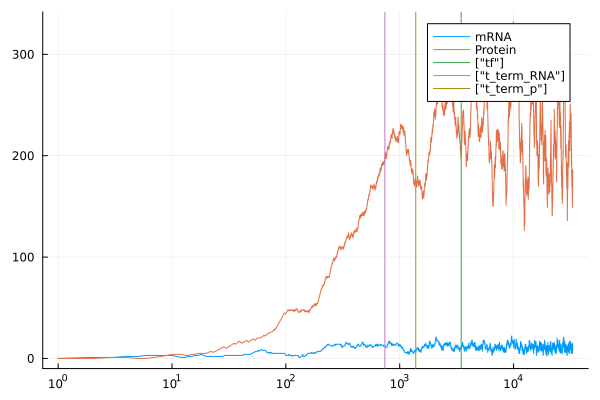

In [31]:
#Time for thermalization
tf = 10 * log(2) / k_deg_p
println(tf)

res = ssa(x0,F,nu,parms,10*tf)
time_steps = res.time
mRNA_steady = res.data[end,1]
p_steady = res.data[end,2]

var_mRNA = (mRNA_steady*ones(length(res.data[:, 1])) .- res.data[:, 1]) / mRNA_steady
var_p = (p_steady*ones(length(res.data[:, 2])) .- res.data[:, 2]) / p_steady

println(mRNA_steady)
println(p_steady)

t_val = findfirst(tf .< res.time)

av_RNA = mean(res.data[t_val:end, 1])
av_p = mean(res.data[t_val:end, 2])

num_term_RNA = findfirst(res.data[:, 1] .> av_RNA)
num_term_p = findfirst(res.data[:, 2] .> av_p)

t_term_RNA = res.time[num_term_RNA];
t_term_p = res.time[num_term_p];

plot(res.data[:,1], xscale=:log, label = "mRNA")
plot!(res.data[:,2], xscale=:log, label = "Protein")
#vline!([tf, t_term_RNA, t_term_p], label=["tf", "t_term_RNA", "t_term_p"])
vline!([tf], label=["tf"])
vline!([t_term_RNA], label=["t_term_RNA"])
vline!([t_term_p], label=["t_term_p"])



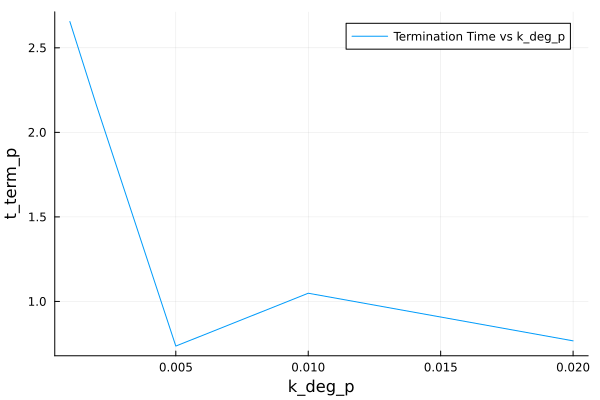

In [32]:
Nsim = 1000
k_deg_p_list = [0.001, 0.002, 0.005, 0.01, 0.02]
t_term_list = zeros(length(k_deg_p_list))
t_term_list_sim = zeros(length(k_deg_p_list))
for i in 1:Nsim
    t_term_list_sim .= 0

    for (i, k_deg_p) in enumerate(k_deg_p_list)
        parms=[k_transcr,k_deg_t,k_transl,k_deg_p]
        tf = 10 * log(2) / k_deg_p
        res = ssa(x0,F,nu,parms,10*tf)
        time_steps = res.time
        mRNA_steady = res.data[end,1]
        p_steady = res.data[end,2]
        av_p = mean(res.data[:, 2])
        num_term_p = findfirst(res.data[:, 2] .> av_p)
        t_term_p = res.time[num_term_p];
        t_term_list[i] = t_term_p
    end
    t_term_list .+= t_term_list_sim
end
plot(k_deg_p_list, t_term_list./Nsim, xlabel="k_deg_p", ylabel="t_term_p", label="Termination Time vs k_deg_p") 



In [ ]:
#changing k_deg_p parameter
k_deg_p=0.002
parms=[k_transcr,k_deg_t,k_transl,k_deg_p]


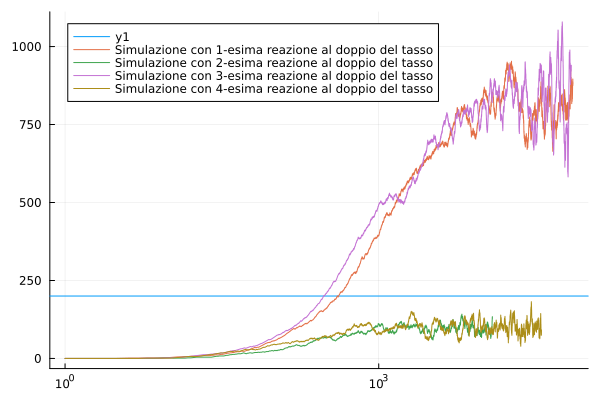

In [33]:
#3 dipendenza di <p> da a e b

a = k_transcr/k_deg_p
b = k_transl / k_deg_t

k_transcr=0.06
k_deg_t=0.006
k_transl=0.04
k_deg_p=0.002

 

parms=[k_transcr,k_deg_t,k_transl,k_deg_p]

x = plot()

hline!([a * b])

for i in 1:4
    parms[i] = parms[i] * 4;

    res = ssa(x0,F,nu,parms,20000.0)
    time_steps = res.time
    mRNA_steady = res.data[end,1]
    p_steady = res.data[end,2]

    
    plot!(res.data[:,2], xscale=:log10, label="Simulazione con $i-esima reazione al doppio del tasso", legend=:topleft)
    #plot!(res.data[:,1], xscale=:log)

    parms[i] = parms[i]/2
end

x

In [ ]:
#3 

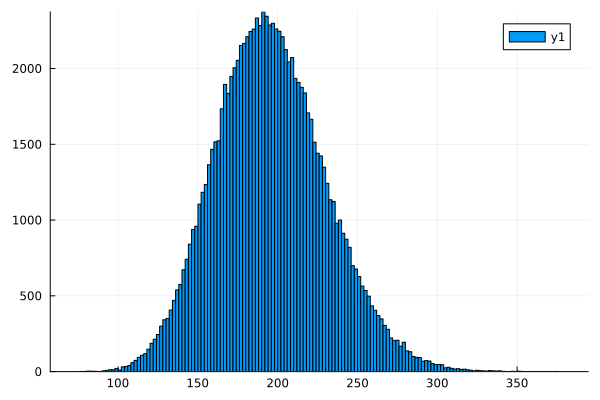

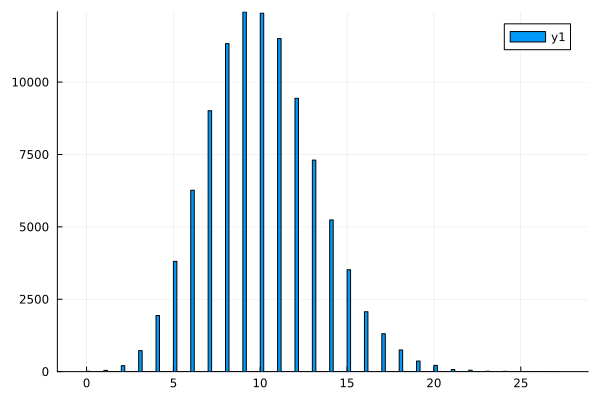

In [34]:
Nsim = 100000;
tf = log(2) / k_deg_p;
RNA_val = zeros(Nsim)
p_val = zeros(Nsim)

for i in 1:Nsim
    res = ssa(x0,F,nu,parms,3*tf)
    RNA_val[i] = res.data[end, 1]
    p_val[i] = res.data[end, 2]
end


histogram(p_val) |> display
histogram(RNA_val) |> display


In [ ]:
@show mean(p_val), var(p_val)
@show mean(RNA_val), var(RNA_val)

In [ ]:
RNA_val = Int.(RNA_val)
count_RNA= zeros(maximum(RNA_val)+1)
for i in 1:length(RNA_val)
    count_RNA[RNA_val[i] + 1] += 1; 
end
count_RNA ./= sum(count_RNA)

In [ ]:
x = 0:1:maximum(RNA_val)
G = Normal(mean(RNA_val), sqrt(var(RNA_val)))
plot(count_RNA, label="Plot dei dati", legend=:bottomright)
plot!(x, pdf.(Poisson(mean(RNA_val)), x), label="Distribuzione di Poisson con media pari a $(round(mean(RNA_val), digits = 2))")
plot!(x, pdf.(G,x), label="Distribuzione normale con media pari a $(round(mean(RNA_val), digits = 2)) e varianza $(round(var(RNA_val), digits = 2))")


In [ ]:
#Ergodicity
tf = 2*10e5;
res = ssa(x0,F,nu,parms,tf)
mRNA_traj = res.data[:,1]

In [ ]:
Nsweep = 10^5
x = zeros(Nsweep)
Tend = length(mRNA_traj)
Tstart = 80000
DeltaT = round((Tend - Tstart)/Nsweep, RoundDown) |> Int

for i in 1:Nsweep
    x[i] = mRNA_traj[Tstart + (i-1) * DeltaT]
end
x
pacf(mRNA_traj, vec(1:5))

In [ ]:
x = Int.(x)
x_val= zeros(maximum(x)+1)
for i in 1:length(x)
    x_val[x[i] + 1] += 1; 
end
x_val ./= sum(x_val)

In [ ]:
plot(x_val, label="Plot dei dati", legend=:bottomright)
plot!(count_RNA, label="Count RNA", legend=:bottomright)

In [ ]:
@show mean(x), var(x)
@show mean(RNA_val), var(RNA_val)

In [ ]:
function F(x,parms)
    
    promoter, mRNA, p = x

    (k_ON, k_OFF, k_transcr,k_deg_t,k_transl,k_deg_p) = parms
    
    activation = k_ON * (1-promoter)
    inhibition = k_OFF * promoter
    transcription = k_transcr * promoter
    mRNA_degradation = k_deg_t*mRNA
    translation = k_transl*mRNA
    p_degradation = k_deg_p*p
    
    [activation, inhibition, transcription, mRNA_degradation, translation, p_degradation]
end

In [ ]:
nu = [
    [1 0 0]; #promoter attivato
    [-1 0 0]; #promoter disattivato
    [0 1 0];
    [0 -1 0];
    [0 0 1];
    [0 0 -1]]

In [ ]:
# esempio singola simulazione

# condizioni iniziali specie
x0=[1, 0, 0]

#valori rate
k_ON = 0.5
k_OFF = 0.0005
k_transcr=0.06
k_deg_t=0.006
k_transl=0.04
k_deg_p=0.002
      
#array parametri
parms=[k_ON, k_OFF, k_transcr,k_deg_t,k_transl,k_deg_p]

#tempo max
t_f = 200000.0

#simulazione
res = ssa(x0,F,nu,parms,t_f)

#step temporali
time_steps = res.time

#traiettoria specie 1 (promoter)
prom_traj = res.data[:,1]

#traiettoria specie 2 (mRNA)
mRNA_traj = res.data[:,2]

#traiettoria specie 3 (proteina)
p_traj = res.data[:,3]

In [ ]:
plot(p_traj)

In [ ]:
plot(prom_traj, marker=:o)